# AutoML & Hyperparameters search

@author: Artamonov Sergey

1. Оптимизация гиперпараметров. Random search
2. Байесовская оптимизация
3. Optuna
4. Генетические алгоритмы
5. Lama

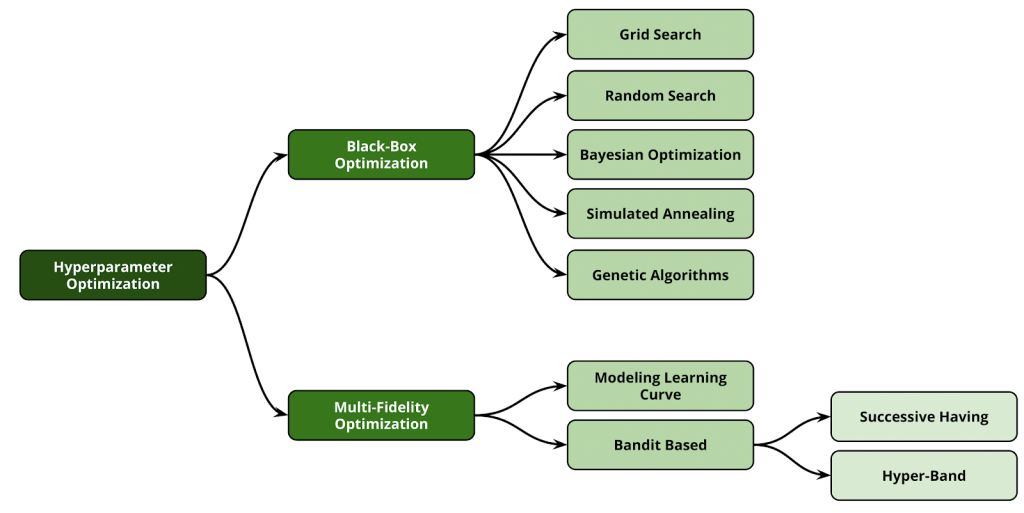

*Источник: Automated Machine Learning: State-of-The-Art and Open Challenges*

Оптимизация гиперпараметров - ключевая задача автоматического машинного обучения. Несмотря на то, что задача представляет из себя, казалось бы, привычную задачу минимизации целевой функции, в случае с гиперпараметрами существует объективная сложность: целевая функция оказывается недифференцируемой. Классические подходы в этой ситуации оказываются бессильны. Тем не менее, существует ряд эффективных подходов для оптимизации гиперпараметров алгоритмов ML и DL.

Постановка задачи подбора гиперпараметров состоит в выборе наилучшей комбинации гиперпараметров с ограничением, заданным в виде некоторого лимита по вычислениям - временного или лимита по выполнению операций.

# Random Search

Самый простой и известный метод оптимизации гиперпараметров - это random search.

Random search появился как модификация Grid search в силу фундаментальных недостатков последнего. Random search позволяет перебрать большее количество всевозможных разнообразных комбинаций параметров, чем Grid Search, а также не требует заранее задавать сетку для перебора параметров. Сложность grid search растёт экспоненциально при увеличении размерности вектора перебираемых параметров, в случае с Random Search эту проблему можно обойти, жертвуя полнотой перебираемых параметров.

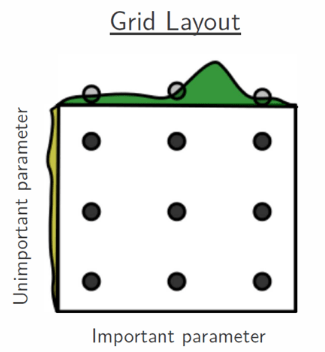

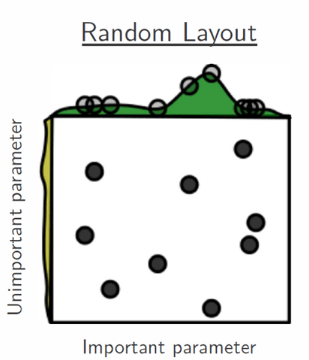

Изображение из статьи *Random Search for Hyper-Parameter Optimization*

Grrid Search и Random Search реализованы в `sklearn`.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

def compare_search_methods(X, y, model, param_grid, n_iter=10, test_size=0.2):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Grid Search
    start_time = time.time()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    grid_search_time = time.time() - start_time

    # Random Search
    start_time = time.time()
    random_search = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=n_iter, cv=5, scoring='accuracy')
    random_search.fit(X_train, y_train)
    random_search_time = time.time() - start_time

    # Estimate
    grid_search_accuracy = accuracy_score(y_test, grid_search.predict(X_test))
    random_search_accuracy = accuracy_score(y_test, random_search.predict(X_test))

    print("Результаты с Grid Search:")
    print("Лучшие параметры:", grid_search.best_params_)
    print("Точность на тестовом наборе:", grid_search_accuracy)
    print("Время выполнения:", grid_search_time, "сек")

    print("Результаты с Random Search:")
    print("Лучшие параметры:", random_search.best_params_)
    print("Точность на тестовом наборе:", random_search_accuracy)
    print("Время выполнения:", random_search_time, "сек")

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

model = RandomForestClassifier()
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
compare_search_methods(X, y, model, param_grid)

Результаты с Grid Search:
Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Точность на тестовом наборе: 1.0
Время выполнения: 31.560442209243774 сек
Результаты с Random Search:
Лучшие параметры: {'n_estimators': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
Точность на тестовом наборе: 1.0
Время выполнения: 3.083146095275879 сек


# Байесовская оптимизация

Байесовская оптимизация - набор методов, основанных на идее оценки апостериорной вероятности нахождения минимума оптимизируемой функции в определённом интервале.

Главная проблема - дороговизна вычисления значения оптимизируемой функции. Идея решения: приблизить её более "дешевыми" и оценить распределение минимума. Суррогатные функции (функции, при помощи которых строится приближение) обозначим за $\hat f$. Для каждого $x$ мы получаем также оценку uncertancy - дисперсии значения суррогатной модели $\hat σ(x)$. Процесс итеративный, каждое следующее приближение выбирается с учётом одного из двух методов:

1. Exploitation
$$x_{n+1} = argmin \hat f(x)$$

2. Exploration
$$x_{n+1} = argmax \hat σ(x)$$

На практике работают с их взвешенной комбинацией - acquistion function.



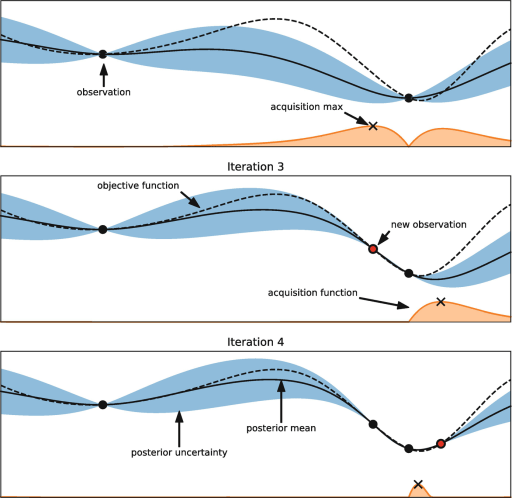

Изображение из главы Hyperparameter Optimization книги об AutoML, авторы Матиас Фойер, Фрэнк Хаттер

Воспользуемся методом байесовской оптимизации из библиотеки `scikit-optimize`.

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.4 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real

In [ ]:
model = RandomForestClassifier()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BayesSearchCV Search
start_time = time.time()
b_search = BayesSearchCV(model, param_grid, n_iter=10, cv=5, scoring='accuracy')
b_search.fit(X_train, y_train)
b_search_time = time.time() - start_time


# Estimate
b_search_accuracy = accuracy_score(y_test, b_search.predict(X_test))

In [ ]:
print("Результаты с Bayes Search:")
print("Лучшие параметры:", b_search.best_params_)
print("Точность на тестовом наборе:", b_search_accuracy)
print("Время выполнения:", b_search_time, "сек")

Результаты с Bayes Search:
Лучшие параметры: OrderedDict([('max_depth', 5), ('min_samples_leaf', 1), ('min_samples_split', 10), ('n_estimators', 100)])
Точность на тестовом наборе: 1.0
Время выполнения: 9.723167419433594 сек


Можно изменить суррогатную функцию при помощи использования аргумента `optimizer_kwargs`

In [ ]:
import time
model = RandomForestClassifier()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BayesSearchCV Search
start_time = time.time()
b_search = BayesSearchCV(model, param_grid, n_iter=10, cv=5, scoring='accuracy', optimizer_kwargs={'base_estimator': 'RF'})
b_search.fit(X_train, y_train)
b_search_time = time.time() - start_time


# Estimate
b_search_accuracy = accuracy_score(y_test, b_search.predict(X_test))

In [ ]:
print("Результаты с Bayes Search RF:")
print("Лучшие параметры:", b_search.best_params_)
print("Точность на тестовом наборе:", b_search_accuracy)
print("Время выполнения:", b_search_time, "сек")

Результаты с Bayes Search RF:
Лучшие параметры: OrderedDict([('max_depth', 5), ('min_samples_leaf', 2), ('min_samples_split', 10), ('n_estimators', 10)])
Точность на тестовом наборе: 1.0
Время выполнения: 9.724960565567017 сек


# Optuna

На практике для оптимизации гиперпараметров очень часто используют `optuna`. `Optuna` - это фреймворк для оптимизации гиперпараметров, реализующий гибкую структуру оптимизируемых функций, входных параметров и реализующий набор алгоритмов дискретной и непрерывно оптимизации. По `Optuna` существует большое количество туториалов и документации.

Мы воспольззуемся этим фреймворком для подбора гиперпараметров в нашей задаче.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.1 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Загрузка датасета
iris = load_iris()
X, y = iris.data, iris.target

# Разделение датасета на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Определение гиперпараметров для оптимизации
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_depth = trial.suggest_int('max_depth', 2, 32, log=True)
    min_samples_split = trial.suggest_float('min_samples_split', 0.1, 1.0)
    min_samples_leaf = trial.suggest_float('min_samples_leaf', 0.1, 0.5)

    # Создание модели RandomForestClassifier с определенными гиперпараметрами
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Вычисление accuracy
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

# Создание study object и запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2026-02-16 17:09:14,010] A new study created in memory with name: no-name-a70b6556-88f7-4a8a-8c1a-892dda60c85d
[I 2026-02-16 17:09:14,046] Trial 0 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 15, 'max_depth': 15, 'min_samples_split': 0.458734050782417, 'min_samples_leaf': 0.3257562344367101}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-02-16 17:09:14,082] Trial 1 finished with value: 0.3 and parameters: {'n_estimators': 19, 'max_depth': 3, 'min_samples_split': 0.7642803045008615, 'min_samples_leaf': 0.3706630896880009}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-02-16 17:09:14,127] Trial 2 finished with value: 0.3 and parameters: {'n_estimators': 26, 'max_depth': 11, 'min_samples_split': 0.81151865112727, 'min_samples_leaf': 0.28944355962524404}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-02-16 17:09:14,268] Trial 3 finished with value: 0.3 and parameters: {'n_estimators': 76, 'max_depth': 5, 'min_samples_split': 0.79

Напишем функцию, которая суммаризирует результат подбора

In [ ]:
def summarize_study(study):
  print("Number of finished trials: {}".format(len(study.trials)))
  print("Best trial:")
  trial = study.best_trial
  print("  Value: {}".format(trial.value))
  print("  Params: ")
  for key, value in trial.params.items():
      print("    {}: {}".format(key, value))

summarize_study(study)

Number of finished trials: 40
Best trial:
  Value: 1.0
  Params: 
    n_estimators: 84
    max_depth: 30
    min_samples_split: 0.5154268611351669
    min_samples_leaf: 0.17389092725804833


## Визуализации в optuna

In [ ]:
# Воспользуемся инструментом визуализации
from matplotlib import pyplot as plt
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
optuna.visualization.plot_slice(study)

# Генетические алгоритмы

Генетические алгоритмы – это метод оптимизации, вдохновленный принципами естественного отбора и генетики. В основе генетических алгоритмов лежит идея создания популяции индивидуальных решений, которые затем итеративно модифицируются и оцениваются, эмулируя эволюцию. В каждой итерации генетического алгоритма, решения подвергаются операциям отбора, скрещивания и мутации, что позволяет сохранять лучшие характеристики найденных решений.

Задача подбора гиперпараметров - это задача оптимизации, которую можно попробовать решить при помощи генетических алгоритмов. Мы воспользуемся библиотекой `deap`, в которой реализованы подходы работы с генетическими алгоритмами. Воспользуемся ими для решения нашей задачи.

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
import random
import deap
from deap import base, creator, tools

# Определение пространства параметров
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4]
}

# Определение функции оценки
def evaluate_individual(individual):
    # Извлечение параметров из индивида
    params = {
        'n_estimators': individual[0],
        'max_depth': individual[1],
        'min_samples_split': individual[2],
        'min_samples_leaf': individual[3]
    }

    # Инициализация и оценка модели
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)

    return accuracy,

# Настройка DEAP
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

# Регистрация операций для генетического алгоритма
toolbox.register("attr_int", random.choice, param_grid['n_estimators'])
toolbox.register("attr_int", random.choice, param_grid['max_depth'])
toolbox.register("attr_int", random.choice, param_grid['min_samples_split'])
toolbox.register("attr_int", random.choice, param_grid['min_samples_leaf'])

## Создаем функцию для генерации одного индивида
## initCycle будет последовательно применять attr_int 4 раза, создавая индивид с четырьмя параметрами: n_estimators, max_depth, min_samples_split и min_samples_leaf.
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.attr_int,), n=4)

## Создает функцию для генерации популяции. tools.initRepeat будет повторять создание индивидов столько раз, сколько указано при вызове функции.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

## Регистрирует оператор скрещивания (кроссовера) двухточечного типа.
toolbox.register("mate", tools.cxTwoPoint)

## Регистрирует оператор мутации, который:
### С вероятностью 0.2 (indpb=0.2) изменяет каждый параметр
### Заменяет выбранный параметр на случайное целое число от 2 до 100
toolbox.register("mutate", tools.mutUniformInt, low=2, up=100, indpb=0.2)

## Регистрирует турнирный отбор с размером турнира 3. При отборе случайным образом выбираются 3 индивида, и лучший из них попадает в следующее поколение
toolbox.register("select", tools.selTournament, tournsize=3)

## Регистрирует функцию оценки качества индивида. evaluate_individual должна принимать индивид и возвращать кортеж с значениями фитнеса, показывающими качество параметров модели
toolbox.register("evaluate", evaluate_individual)

# Определение параметров и запуск генетического алгоритма
population_size = 10
generations = 5
pop = toolbox.population(n=population_size)
for gen in range(generations):
    offspring = [toolbox.clone(ind) for ind in pop]

    # Скрещивание
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.5:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # Мутация
    for mutant in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Оценка потомков, которые изменились
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Замена старой популяции на новую
    pop[:] = offspring

# Вывод результатов
best_individual = tools.selBest(pop, k=1)[0]
best_params = {
    'n_estimators': best_individual[0],
    'max_depth': best_individual[1],
    'min_samples_split': best_individual[2],
    'min_samples_leaf': best_individual[3]
}
print("Лучшие параметры:", best_params)

/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning:

A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.

/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning:

A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.



Лучшие параметры: {'n_estimators': 4, 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 4}


#### Двухточечный кроссовер

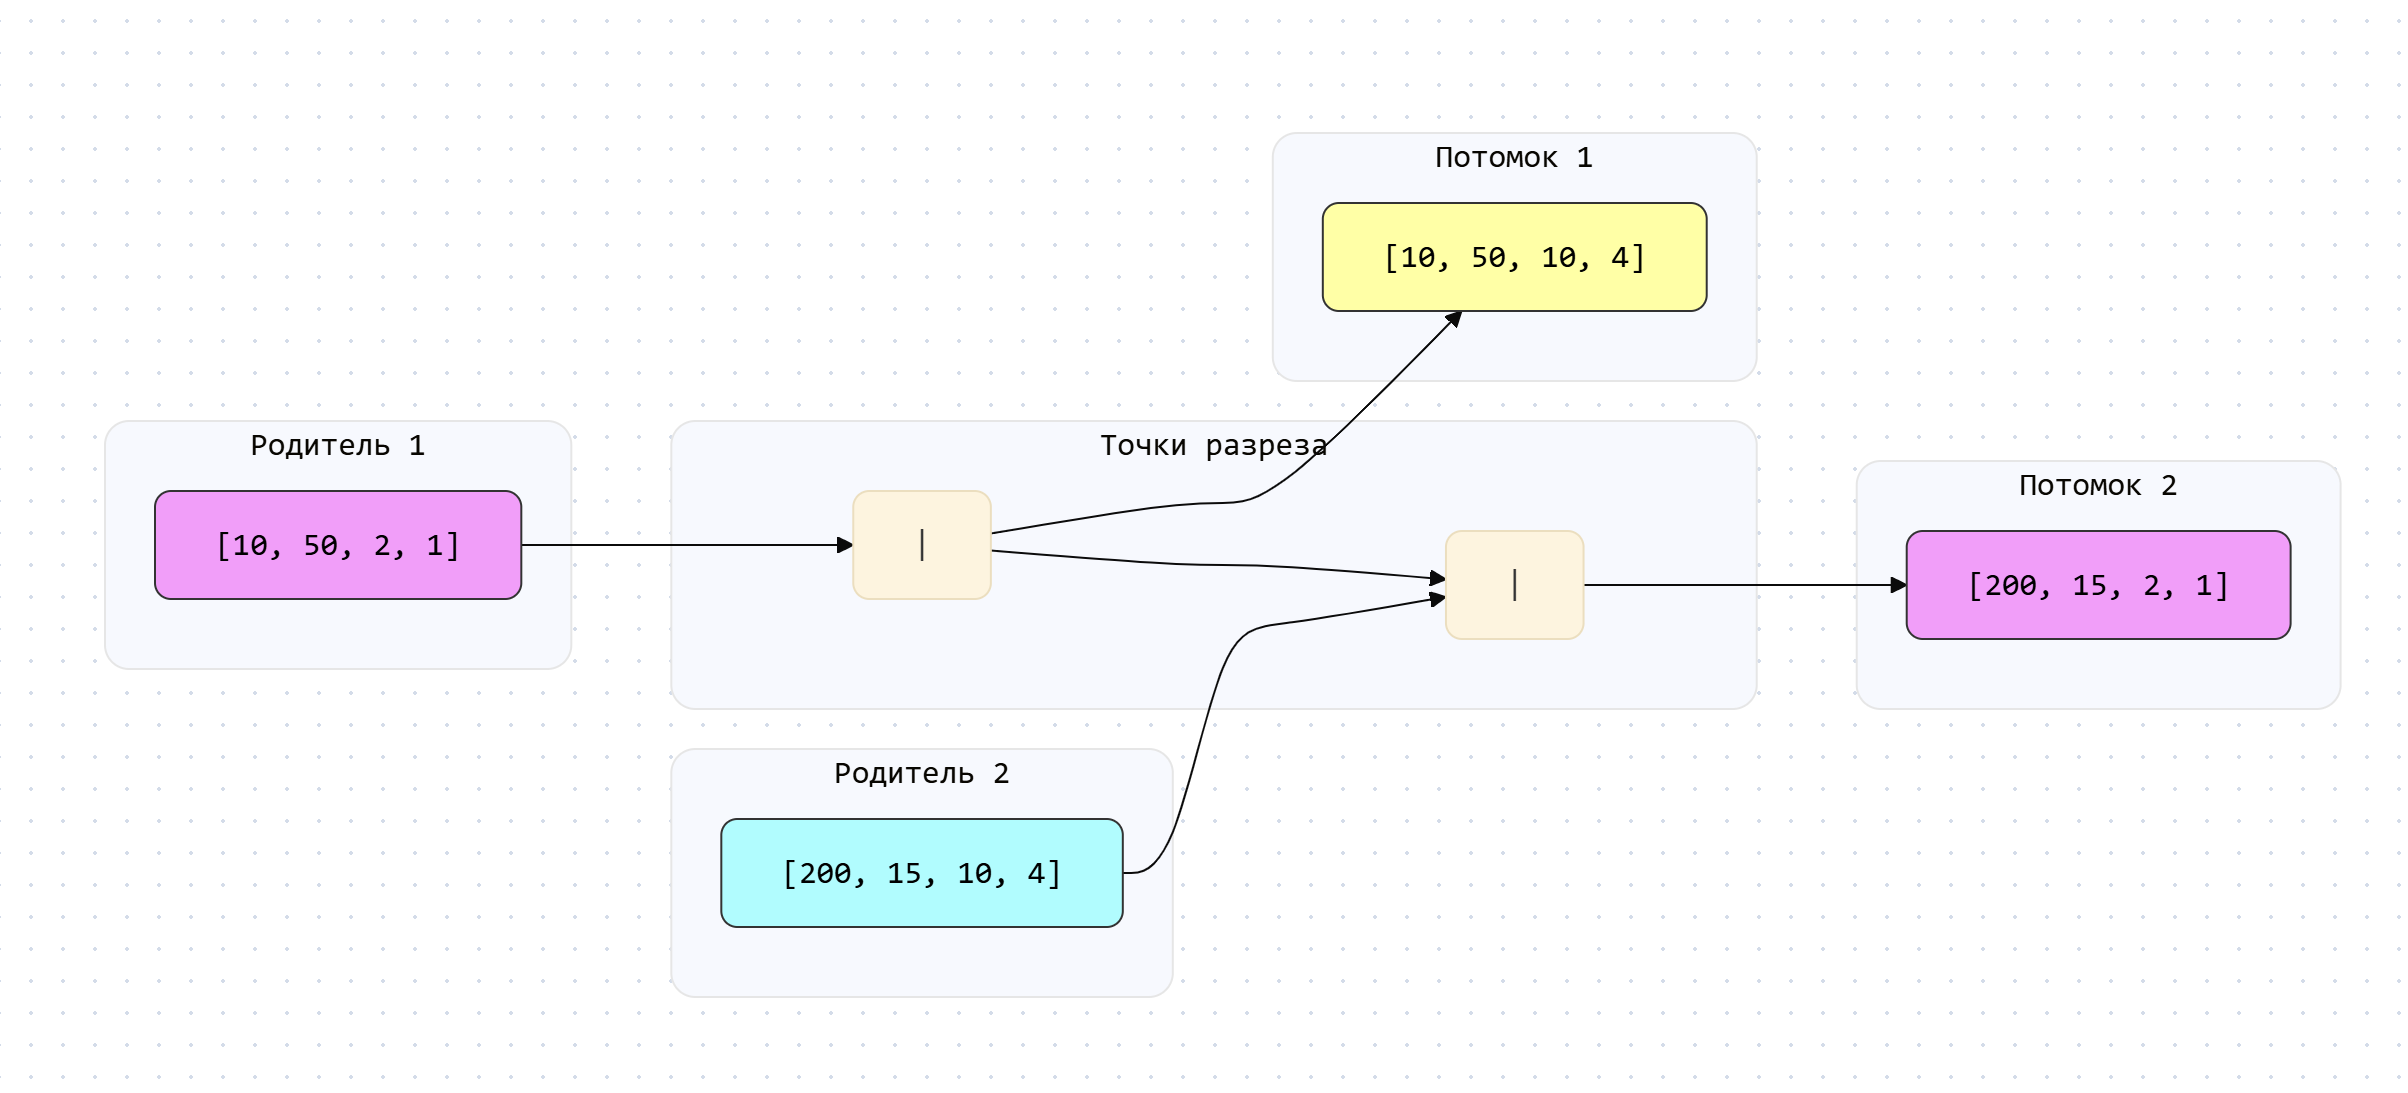

In [ ]:
evaluate_individual(best_individual)

(1.0,)

# AutoML

[Немного интересного с кэггла](https://www.kaggle.com/automl-grand-prix)

При работе с AutoML обычно говорят о задаче автоматического построения оптимального пайплайна обучения. Пайплайн (последовательность операций, производимых с данными) можно понимать как совокупность большого числа гиперпараметров, поэтому эта задача родственная задаче автоматического поиска гиперпараметров.

*Далее - компиляция фрагментов статей, переведенных с английского языка chatgpt*

---------------------
Пусть $ P(D) $ — это распределение наборов данных, из которого можно выбирать распределение отдельного набора данных $ P_d = P(X, y) $.

Задача AutoML состоит в том, чтобы построить обученный пайплайн $ M_\lambda : x \rightarrow y $, параметризованный гиперпараметрами $ \lambda \in \Lambda $, который автоматически формирует предсказания для выборок из распределения $ P_d $, минимизируя ошибку обобщения:

$$
GE(M_\lambda) = \int L(M_\lambda(x), y), P_d(x,y), dx, dy.
$$

Поскольку распределение набора данных можно наблюдать только через конечное множество из $ n $ независимых наблюдений

$$
D_d = {(x_1,y_1), \dots, (x_n,y_n)} \sim P_d,
$$

мы можем лишь эмпирически оценить ошибку обобщения по выборке:

$$
GE(M_\lambda, D_d) = \frac{1}{|D_d|} \sum_{(x_i,y_i)\in D_d} L(M_\lambda(x_i), y_i).
$$

Системы AutoML автоматически ищут наилучшую модель $ M_{\lambda^*} $:

$$
M_{\lambda^*} \in \arg\min_{\lambda \in \Lambda} GE(M_\lambda, D_{train}),
$$

и оценивают ошибку приближения, например, с помощью  кросс-валидации:

$$
GE_{CV}(M_\lambda, D_{train}) = \frac{1}{k} \sum_{i=1}^{k}
GE\big(M^{D_{train}^{(train,i)}}*\lambda, D*{train}^{(val,i)}\big),
$$

где $ M^{D_{train}^{(train,i)}}*\lambda $ обозначает модель $ M*\lambda $, обученную на $ i $-й части $ D_{train}^{(train,i)} $.

Если предположить, что система AutoML может выбирать через $\lambda$ как сам алгоритм, так и его гиперпараметры, то данное определение с использованием $ GE_{CV} $ эквивалентно формулировке задачи CASH (Combined Algorithm Selection and Hyperparameter optimization — совместный выбор алгоритма и оптимизация гиперпараметров).


На практике пользователи заинтересованы не только в том, чтобы в конечном итоге получить оптимальный конвейер $ M_{\lambda^*} $, но и имеют ограничения по времени и вычислительным ресурсам, которые они готовы затратить. Обозначим через $ t_\lambda $ время, необходимое для оценки $ GE(\lambda, D_{train}) $, а через $ T $ — общий бюджет времени на оптимизацию. Тогда наша цель — найти

$$
M_{\lambda^*} \in \arg\min_{\lambda \in \Lambda} GE(\lambda, D_{train})
\quad \text{при условии} \quad
t_\lambda < T,
$$

где суммарное время вычислений берётся по всем оценённым конвейерам.


-----------------------
Существует несколько популярных AutoML-фреймворков

1. MLBox - часто попадает в топ рейтинга на kaggle

2. Auto sklearn - фреймворк семейства sklearn. Pipeline содержит следующие структурные элементы: Генерация признаков, hyperopt, model selection

3. H2O - в основном используется для работы с нейронками

4. Lightautoml - фреймворк от сбера, поддерживает большое количество структурных элементов в пйаплайне, оптимизирует при помощи optuna, поддерживает работу с временными рядами

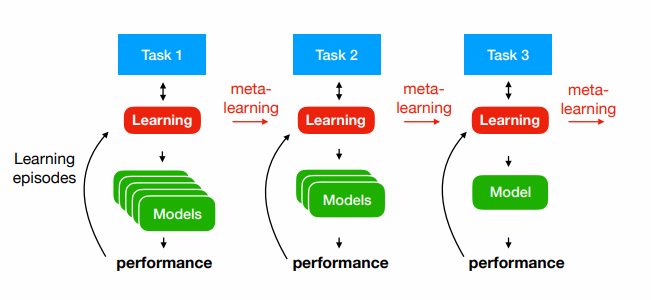

### Auto sklearn

[Github](https://automl.github.io/auto-sklearn/master/)

[Auto-sklearn 2.0: The next generation](https://www.researchgate.net/profile/Matthias-Feurer/publication/342801746_Auto-Sklearn_20_The_Next_Generation/links/5f7c334aa6fdccfd7b4a87de/Auto-Sklearn-20-The-Next-Generation.pdf)

Auto-sklearn — это библиотека для автоматизированного машинного обучения (AutoML), построенная поверх scikit-learn. Она автоматически подбирает алгоритм, гиперпараметры и даже предобработку данных для задачи классификации или регрессии. В основе её работы лежит байесовская оптимизация (SMBO), которая последовательно исследует пространство моделей и находит наиболее перспективные конфигурации. Auto-sklearn также использует мета-обучение: опираясь на опыт решения похожих задач, система быстрее находит хорошие стартовые решения. Финальная модель обычно представляет собой ансамбль нескольких лучших найденных моделей



## H2O

In [ ]:
pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 4.6 MB/s eta 0:00:00


In [ ]:
import h2o
from h2o.automl import H2OAutoML
from sklearn.datasets import load_iris
import pandas as pd

# Запуск H2O-кластера
h2o.init()

# Загружаем данные
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

# Переводим в H2OFrame
hf = h2o.H2OFrame(df)

# Указываем целевую переменную и признаки
x = iris.feature_names
y = "target"

# Для классификации target должен быть категориальным
hf[y] = hf[y].asfactor()

# Делим на train/test
train, test = hf.split_frame(ratios=[0.8], seed=42)

# Создаем AutoML-объект
aml = H2OAutoML(
    max_runtime_secs=60,
    seed=42,
    balance_classes=True
)

# Обучение
aml.train(x=x, y=y, training_frame=train)

# Leaderboard
lb = aml.leaderboard
print(lb.head())

# Лучшая модель
best_model = aml.leader

# Предсказания
preds = best_model.predict(test)
print(preds.head())


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpiy854cvq
  JVM stdout: /tmp/tmpiy854cvq/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpiy854cvq/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,08 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 23 days
H2O_cluster_name:,H2O_from_python_unknownUser_l7nvg9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████████████████████████
17:33:42.629: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 121.0.

█████████████████████████████████████| (done) 100%
model_id                                                   mean_per_class_error    logloss      rmse        mse
GLM_1_AutoML_1_20260216_173316                                        0.0337607  0.0659531  0.144803  0.020968
XGBoost_2_AutoML_1_20260216_173316                                    0.0423077  0.208302   0.219617  0.0482317
StackedEnsemble_BestOfFamily_3_AutoML_1_20260216_173316               0.050641   0.224146   0.231376  0.0535348
GBM_grid_1_AutoML_1_20260216_173316_model_1                           0.050641   0.153069   0.202089  0.0408401
XGBoost_3_AutoML_1_20260216_173316                                    0.050641   0.170778   0.20

## Light AutoML

[LightAutoML: AutoML Solution for a Large Financial Services
Ecosystem](https://arxiv.org/pdf/2109.01528)

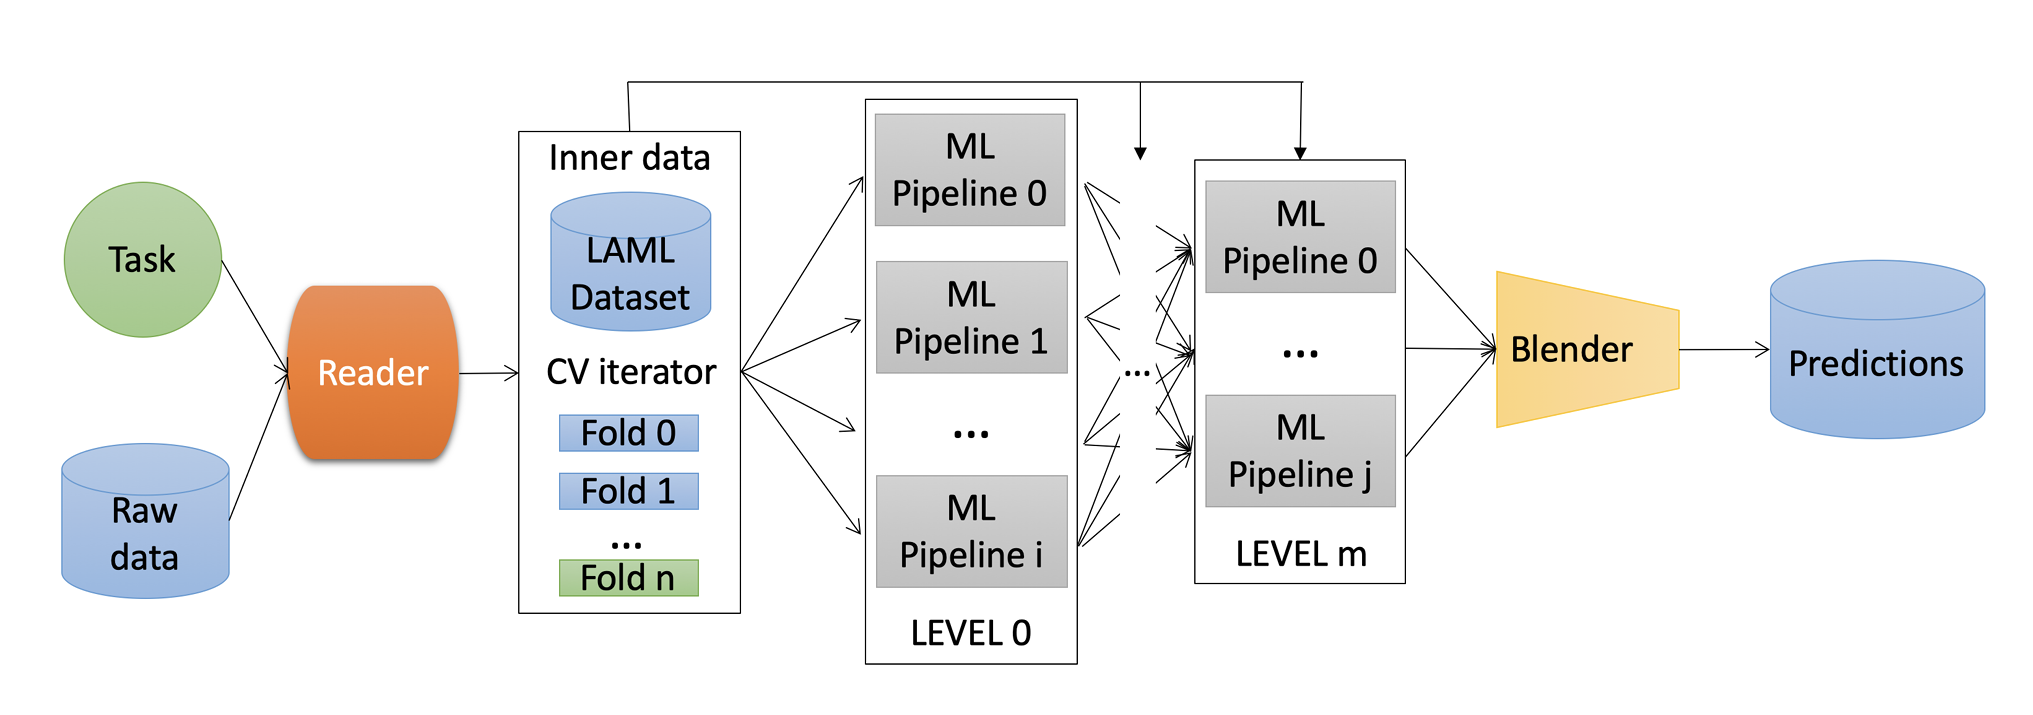

In [ ]:
!pip install -U lightautoml

In [ ]:
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task
from sklearn.metrics import accuracy_score

/usr/local/lib/python3.12/dist-packages/lightautoml/transformers/text.py:23: UserWarning: 'fasttext' - package isn't installed
  warnings.warn("'fasttext' - package isn't installed")


Заводим объект класса `Task`, в аргумент передаем тип решаемой задачи:

In [ ]:
task = Task("multiclass")#, metric=lambda y_true, y_pred: accuracy_score(y_true, y_pred))

А также объект `TabularAutoML`:



In [ ]:
automl = TabularAutoML(task)

`Lama` предпочитает работать с `pandas`.

In [ ]:
import pandas as pd
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df_train, df_test = train_test_split(df, train_size=0.8, random_state=42, shuffle=True)

Обучаем automl

In [ ]:
oof_pred = automl.fit_predict(
    df_train,
    roles = {'target': 'target'}
)

INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: multiclass

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 3600.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (120, 5)

INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 3591.57 secs
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
DEBUG:lightautoml.ml_algo.base:Training params: {'tol': 1e-06, 'max_iter': 100, 'cs': [1e-05, 5e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000], 'early_stopping': 2, 'categorical_idx': [], 'embed_sizes': (), 'data_size': 4}
INFO2:lightautoml.ml_algo.base:===== Star

Получим прогноз итоговой модели

In [ ]:
test_pred = automl.predict(df_test)

In [ ]:
test_pred

array([[2.9207896e-03, 9.7504711e-01, 2.2032138e-02],
       [9.9222505e-01, 6.3182949e-03, 1.4565603e-03],
       [1.4217473e-04, 1.1799836e-03, 9.9867785e-01],
       [3.3861890e-03, 9.5525247e-01, 4.1361384e-02],
       [2.8830084e-03, 9.2099684e-01, 7.6120123e-02],
       [9.9200058e-01, 6.2001115e-03, 1.7993156e-03],
       [4.8817145e-03, 9.8583573e-01, 9.2825610e-03],
       [1.3914405e-03, 1.7255563e-02, 9.8135298e-01],
       [2.5900006e-03, 3.3583155e-01, 6.6157848e-01],
       [2.7032711e-03, 9.8820448e-01, 9.0923160e-03],
       [3.9663357e-03, 1.2636070e-01, 8.6967295e-01],
       [9.9259865e-01, 5.7491167e-03, 1.6522376e-03],
       [9.9283296e-01, 5.7824650e-03, 1.3845882e-03],
       [9.9321938e-01, 5.2238568e-03, 1.5567166e-03],
       [9.9648285e-01, 2.6503329e-03, 8.6676527e-04],
       [4.9850321e-03, 9.5115900e-01, 4.3855965e-02],
       [8.2737085e-04, 5.7287524e-03, 9.9344385e-01],
       [2.7151476e-03, 9.8750287e-01, 9.7819697e-03],
       [3.3117910e-03, 9.761

In [ ]:
type(test_pred)

lightautoml.dataset.np_pd_dataset.NumpyDataset

In [ ]:
import numpy as np
preds = np.argmax(test_pred.data, axis=1)

In [ ]:
accuracy_score(df_test.target, preds)

0.9666666666666667

### Кастомизация пайплайнов в Lama

Следующий раздел содержит фрагменты кода, скопированного из официального туториала.

**Tutorial**: https://colab.research.google.com/github/sberbank-ai-lab/LightAutoML/blob/master/examples/tutorials/Tutorial_6_custom_pipeline.ipynb

In [ ]:
# Installed libraries
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import requests

In [ ]:
# Imports from our package
from lightautoml.automl.base import AutoML
from lightautoml.ml_algo.boost_lgbm import BoostLGBM
from lightautoml.ml_algo.tuning.optuna import OptunaTuner
from lightautoml.pipelines.features.lgb_pipeline import LGBSimpleFeatures
from lightautoml.pipelines.ml.base import MLPipeline
from lightautoml.pipelines.selection.importance_based import ImportanceCutoffSelector, ModelBasedImportanceEstimator
from lightautoml.reader.base import PandasToPandasReader
from lightautoml.tasks import Task
from lightautoml.automl.blend import WeightedBlender

In [ ]:
N_THREADS = 8 # threads cnt for lgbm and linear models
N_FOLDS = 5 # folds cnt for AutoML
RANDOM_STATE = 42 # fixed random state for various reasons
TEST_SIZE = 0.2 # Test size for metric check
TARGET_NAME = 'TARGET' # Target column name

In [ ]:
np.random.seed(RANDOM_STATE)
torch.set_num_threads(N_THREADS)

In [ ]:
DATASET_DIR = '../data/'
DATASET_NAME = 'sampled_app_train.csv'
DATASET_FULLNAME = os.path.join(DATASET_DIR, DATASET_NAME)
DATASET_URL = 'https://raw.githubusercontent.com/sberbank-ai-lab/LightAutoML/master/examples/data/sampled_app_train.csv'

In [ ]:
if not os.path.exists(DATASET_FULLNAME):
    os.makedirs(DATASET_DIR, exist_ok=True)

    dataset = requests.get(DATASET_URL).text
    with open(DATASET_FULLNAME, 'w') as output:
        output.write(dataset)

In [ ]:
data = pd.read_csv(DATASET_FULLNAME)
data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,313802,0,Cash loans,M,N,Y,0,270000.0,327024.0,15372.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,319656,0,Cash loans,F,N,N,0,108000.0,675000.0,19737.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,207678,0,Revolving loans,F,Y,Y,2,112500.0,270000.0,13500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
3,381593,0,Cash loans,F,N,N,1,67500.0,142200.0,9630.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
4,258153,0,Cash loans,F,Y,Y,0,337500.0,1483231.5,46570.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0


In [ ]:
data.shape

(10000, 122)

In [ ]:
data['BIRTH_DATE'] = (np.datetime64('2018-01-01') + data['DAYS_BIRTH'].astype(np.dtype('timedelta64[D]'))).astype(str)
data['EMP_DATE'] = (np.datetime64('2018-01-01') + np.clip(data['DAYS_EMPLOYED'], None, 0).astype(np.dtype('timedelta64[D]'))
                    ).astype(str)

data['constant'] = 1
data['allnan'] = np.nan

data['report_dt'] = np.datetime64('2018-01-01')

data.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

In [ ]:
train_data, test_data = train_test_split(data,
                                         test_size=TEST_SIZE,
                                         stratify=data[TARGET_NAME],
                                         random_state=RANDOM_STATE)
print('Data splitted. Parts sizes: train_data = {}, test_data = {}'
              .format(train_data.shape, test_data.shape))

Data splitted. Parts sizes: train_data = (8000, 125), test_data = (2000, 125)


Что делать, если мы хотим создать свой собственный пайплайн, специфицируя собственные фрагменты для перебора оптимизатором?

В Lama можно кастомизировать решение.

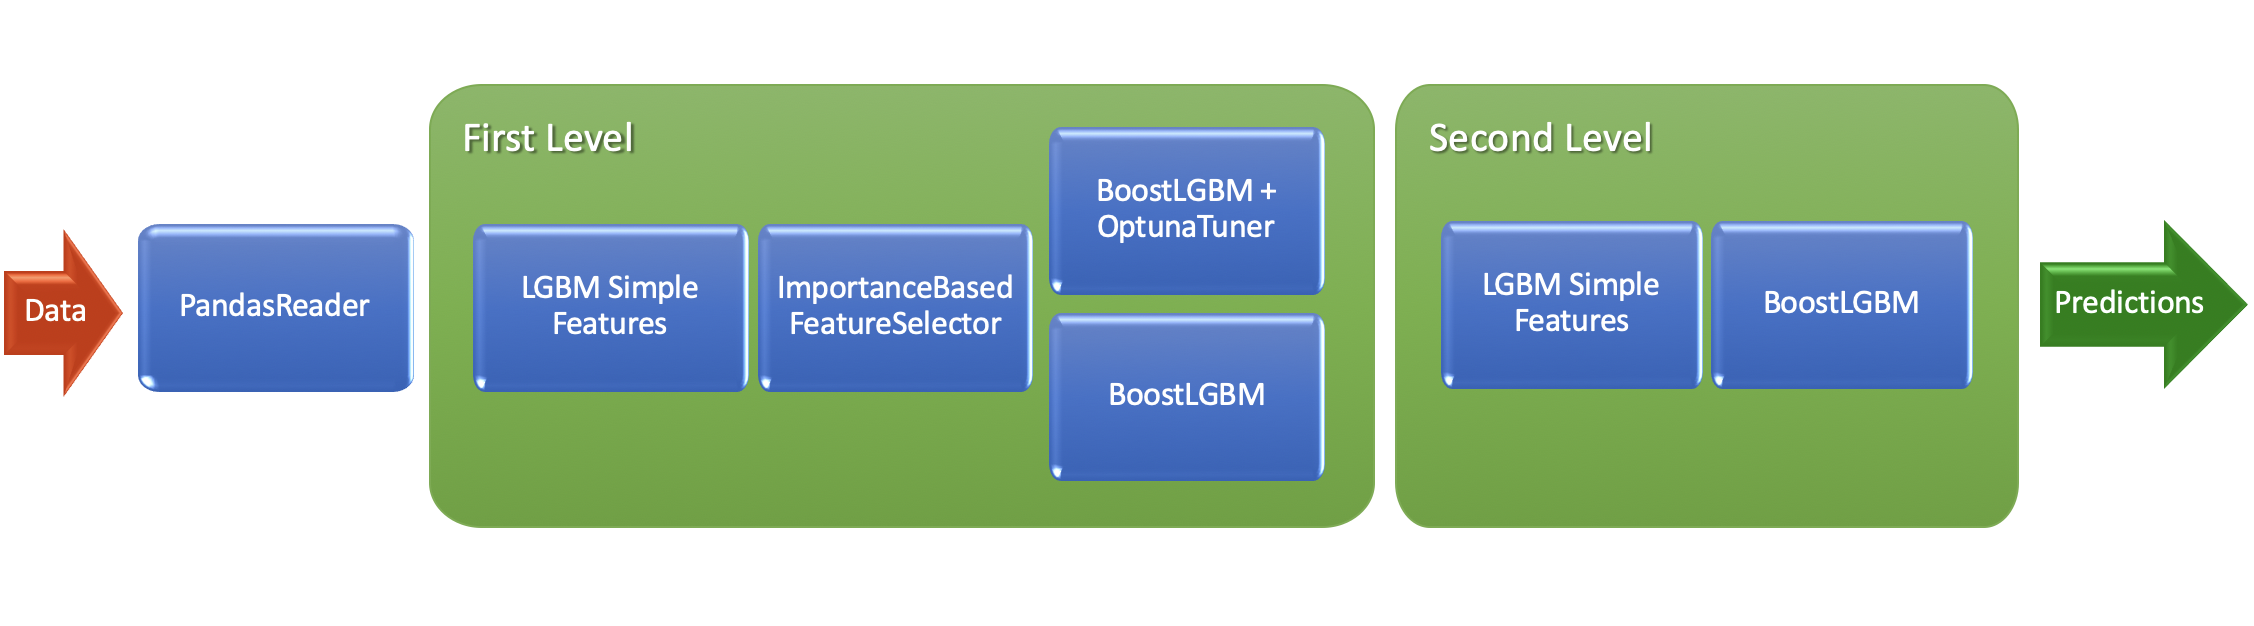

Зададим Task и Reader

In [ ]:
task = Task('binary')
reader = PandasToPandasReader(task, cv=N_FOLDS, random_state=RANDOM_STATE)

Зададим feature selector

- https://lightautoml.readthedocs.io/en/latest/pages/modules/generated/lightautoml.pipelines.features.lgb_pipeline.LGBSimpleFeatures.html
- https://lightautoml.readthedocs.io/en/latest/python_api/generated/lightautoml.pipelines.selection.importance_based.ModelBasedImportanceEstimator.html

In [ ]:
model0 = BoostLGBM(
    default_params={'learning_rate': 0.05, 'num_leaves': 64, 'seed': 42, 'num_threads': N_THREADS}
)
pipe0 = LGBSimpleFeatures()
mbie = ModelBasedImportanceEstimator()
selector = ImportanceCutoffSelector(pipe0, model0, mbie, cutoff=0)

Зададим первый уровень нашего пайплайна. Для этого воспользуемся специальнымм контейнером `MLPipeline`, позволяющим совмещать различные блоки в один пайплайн.

In [ ]:
pipe = LGBSimpleFeatures()

# оптимизатор гиперпараметров
params_tuner1 = OptunaTuner(n_trials=20, timeout=30) # stop after 20 iterations or after 30 seconds

# Первая модель
model1 = BoostLGBM(
    default_params={'learning_rate': 0.05, 'num_leaves': 128, 'seed': 1, 'num_threads': N_THREADS}
)

# Вторая модель
model2 = BoostLGBM(
    default_params={'learning_rate': 0.025, 'num_leaves': 64, 'seed': 2, 'num_threads': N_THREADS}
)


# Весь фрагмент пайплайна целиком
pipeline_lvl1 = MLPipeline([
    (model1, params_tuner1),
    model2
], pre_selection=selector, features_pipeline=pipe, post_selection=None)

Теперь зададим второй уровень нашего пайплайна

In [ ]:
pipe1 = LGBSimpleFeatures()
model = BoostLGBM(
    default_params={'learning_rate': 0.05, 'num_leaves': 64, 'max_bin': 1024, 'seed': 3, 'num_threads': N_THREADS},
    freeze_defaults=True
)

pipeline_lvl2 = MLPipeline([model], pre_selection=None, features_pipeline=pipe1, post_selection=None)

А теперь объединим два уровня в общий пайплайн

In [ ]:
automl = AutoML(reader, [
    [pipeline_lvl1],
    [pipeline_lvl2],
], skip_conn=False)

Обучаем пайплайн

In [ ]:
%%time

oof_pred = automl.fit_predict(train_data, roles={'target': TARGET_NAME})
print('oof_pred:\n{}\nShape = {}'.format(oof_pred, oof_pred.shape))

INFO:lightautoml.reader.base:Train data shape: (8000, 125)

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:37: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: ['REG_REGION_NOT_LIVE_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'FLAG_DOCUMENT_8']
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 9999999979.31 secs
INFO3:lightautoml.ml_algo.boost_lgbm:[LightGBM] [Warning] seed is set=42, random_state=42 will be ignored. Current value: seed=42
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
DEBUG:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.728627
DEBUG:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.726425
DEBUG:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[1

oof_pred:
array([[0.07636376],
       [0.0682414 ],
       [0.06492288],
       ...,
       [0.07770307],
       [0.1642788 ],
       [0.0962216 ]], dtype=float32)
Shape = (8000, 1)
CPU times: user 3min 2s, sys: 48.5 s, total: 3min 50s
Wall time: 3min


In [ ]:
print('Feature importances of selector:\n{}'
              .format(selector.get_features_score()))
print('=' * 70)

print('Feature importances of top level algorithm:\n{}'
              .format(automl.levels[-1][0].ml_algos[0].get_features_score()))
print('=' * 70)

print('Feature importances of lowest level algorithm - model 0:\n{}'
              .format(automl.levels[0][0].ml_algos[0].get_features_score()))
print('=' * 70)

print('Feature importances of lowest level algorithm - model 1:\n{}'
              .format(automl.levels[0][0].ml_algos[1].get_features_score()))
print('=' * 70)

Feature importances of selector:
EXT_SOURCE_2              2194.671469
EXT_SOURCE_3              1889.970800
BIRTH_DATE                1311.145894
DAYS_REGISTRATION         1154.415072
DAYS_LAST_PHONE_CHANGE    1134.185014
                             ...     
FLAG_DOCUMENT_9              0.000000
FLAG_DOCUMENT_13             0.000000
FLAG_DOCUMENT_11             0.000000
EMERGENCYSTATE_MODE          0.000000
FLAG_DOCUMENT_5              0.000000
Length: 107, dtype: float64
Feature importances of top level algorithm:
Lvl_0_Pipe_0_Mod_0_LightGBM_prediction_0    1481.949181
Lvl_0_Pipe_0_Mod_1_LightGBM_prediction_0       0.000000
dtype: float64
Feature importances of lowest level algorithm - model 0:
EXT_SOURCE_2                  1799.807045
EXT_SOURCE_3                  1687.247894
dtdiff__BIRTH_DATE            1262.505539
DAYS_REGISTRATION             1119.394484
DAYS_ID_PUBLISH               1025.645640
                                 ...     
REG_REGION_NOT_WORK_REGION       6.239520

Прогноз на тестовой выборке

In [ ]:
test_pred = automl.predict(test_data)
print('Prediction for test data:\n{}\nShape = {}'
              .format(test_pred, test_pred.shape))

print('Check scores...')
print('Train score: {}'.format(roc_auc_score(train_data[TARGET_NAME].values, oof_pred.data[:, 0])))
print('TEST score: {}'.format(roc_auc_score(test_data[TARGET_NAME].values, test_pred.data[:, 0])))

Prediction for test data:
array([[0.07574282],
       [0.08556643],
       [0.08287806],
       ...,
       [0.06549107],
       [0.07208718],
       [0.11447105]], dtype=float32)
Shape = (2000, 1)
Check scores...
OOF score: 0.687226530551936
TEST score: 0.7272180706521739


### White box Lama

Следующий раздел содержит фрагменты официального туториала.

**Tutorial:** https://colab.research.google.com/github/sberbank-ai-lab/LightAutoML/blob/master/examples/tutorials/Tutorial_2_WhiteBox_AutoWoE.ipynb

Здесь мы поговорим о построении интерпретируемых пайплайнов и их оптимизации.
У Lama есть модуль, выделенный в отдельную библиотеку - `autowoe`, реализующий набор функций для построения интерпретируемых моделей.

In [ ]:
import pandas as pd
from pandas import Series, DataFrame

import numpy as np

import os
import requests
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from autowoe import AutoWoE, ReportDeco

Загрузим датасет

In [ ]:
DATASET_DIR = '../data/'
DATASET_NAME = 'jobs_train.csv'
DATASET_FULLNAME = os.path.join(DATASET_DIR, DATASET_NAME)
DATASET_URL = 'https://raw.githubusercontent.com/sberbank-ai-lab/LightAutoML/master/examples/data/jobs_train.csv'

if not os.path.exists(DATASET_FULLNAME):
    os.makedirs(DATASET_DIR, exist_ok=True)

    dataset = requests.get(DATASET_URL).text
    with open(DATASET_FULLNAME, 'w') as output:
        output.write(dataset)

data = pd.read_csv(DATASET_FULLNAME)
train, test = train_test_split(data.drop('enrollee_id', axis=1), test_size=0.2, stratify=data['target'])

In [ ]:
train.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
17855,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,STEM,10.0,99.0,Pvt Ltd,1.0,90,0.0
17664,city_103,0.920,Male,No relevent experience,no_enrollment,Primary School,NaN,5.0,NaN,NaN,0.0,15,0.0
13404,city_50,0.896,Male,Has relevent experience,no_enrollment,Graduate,STEM,12.0,4999.0,NGO,5.0,36,0.0
13366,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,5.0,500.0,Funded Startup,1.0,53,0.0
15670,city_67,0.855,Female,Has relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,1.0,158,1.0


Зададим класс `AutoWoE` с дефолтными значениями всех параметров

In [ ]:
auto_woe_0 = AutoWoE(interpreted_model=True,
                     monotonic=False,
                     max_bin_count=5,
                     select_type=None,
                     pearson_th=0.9,
                     vif_th=10.,
                     imp_th=0,
                     th_const=32,
                     force_single_split=True,
                     th_nan=0.01,
                     th_cat=0.005,
                     cat_alpha=100,
                     cat_merge_to="to_woe_0",
                     nan_merge_to="to_woe_0",
                     imp_type="feature_imp",
                     regularized_refit=False,
                     p_val=0.05,
                     verbose=2
        )

auto_woe_0 = ReportDeco(auto_woe_0)

In [ ]:
np.str = str
np.bool = bool
np.float = float
np.int = int

In [ ]:
auto_woe_0.fit(train,
               target_name="target",
              )

  _log_warning('Using categorical_feature in Dataset.')

  _log_warning('Overriding the parameters from Reference Dataset.')

  _log_warning('{} in param dict is overridden.'.format(cat_alias))



[LightGBM] [Info] Number of positive: 3033, number of negative: 9227
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 518
[LightGBM] [Info] Number of data points in the train set: 12260, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.247390 -> initscore=-1.112582
[LightGBM] [Info] Start training from score -1.112582


  self.pid = os.fork()



city processing...
city_development_index processing...
gender processing...
relevent_experience processing...
enrolled_university processing...
education_level processing...
major_discipline processing...
experience processing...
company_size processing...
company_type processing...
last_new_job processing...
training_hours processing...
dict_keys(['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']) to selector !!!!!
Feature selection...


  warnings.warn(



city_development_index   -0.955657
company_size             -0.855699
company_type             -0.416587
experience               -0.290657
enrolled_university      -0.258948
education_level          -0.603186
major_discipline         -1.684824
dtype: float64


  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(



In [ ]:
test_prediction = auto_woe_0.predict_proba(test)
test_prediction

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(



array([0.05967091, 0.59486301, 0.02949844, ..., 0.14372036, 0.06455054,
       0.04814369])

In [ ]:
roc_auc_score(test['target'].values, test_prediction)

0.8016602154294667

In [ ]:
report_params = {"output_path": "HR_REPORT_1",
                 "report_name": "WHITEBOX REPORT",
                 "report_version_id": 1,
                 "city": "Moscow",
                 "model_aim": "Predict if candidate will work for the company",
                 "model_name": "HR model",
                 "zakazchik": "Kaggle",
                 "high_level_department": "Ai Lab",
                 "ds_name": "Btbpanda",
                 "target_descr": "Candidate will work for the company",
                 "non_target_descr": "Candidate will work for the company"}

auto_woe_0.generate_report(report_params)

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  ax = sns.barplot(x="WOE: " + column, hue="_sample_", y="Freq", data=total, palette=sns.color_palette("Accent", 7))

  grp = df.groupby(col)["pred", "Target"].mean()

  grp = df.groupby(col)["pred", "Target"].mean()

  grp = df.groupby(col)["pred", "Target"].mean()

  grp = df.groupby(col)[

Сгенерированный отчет содержит большое количество инфографики, позволяющей интерпретировать полученный результат.

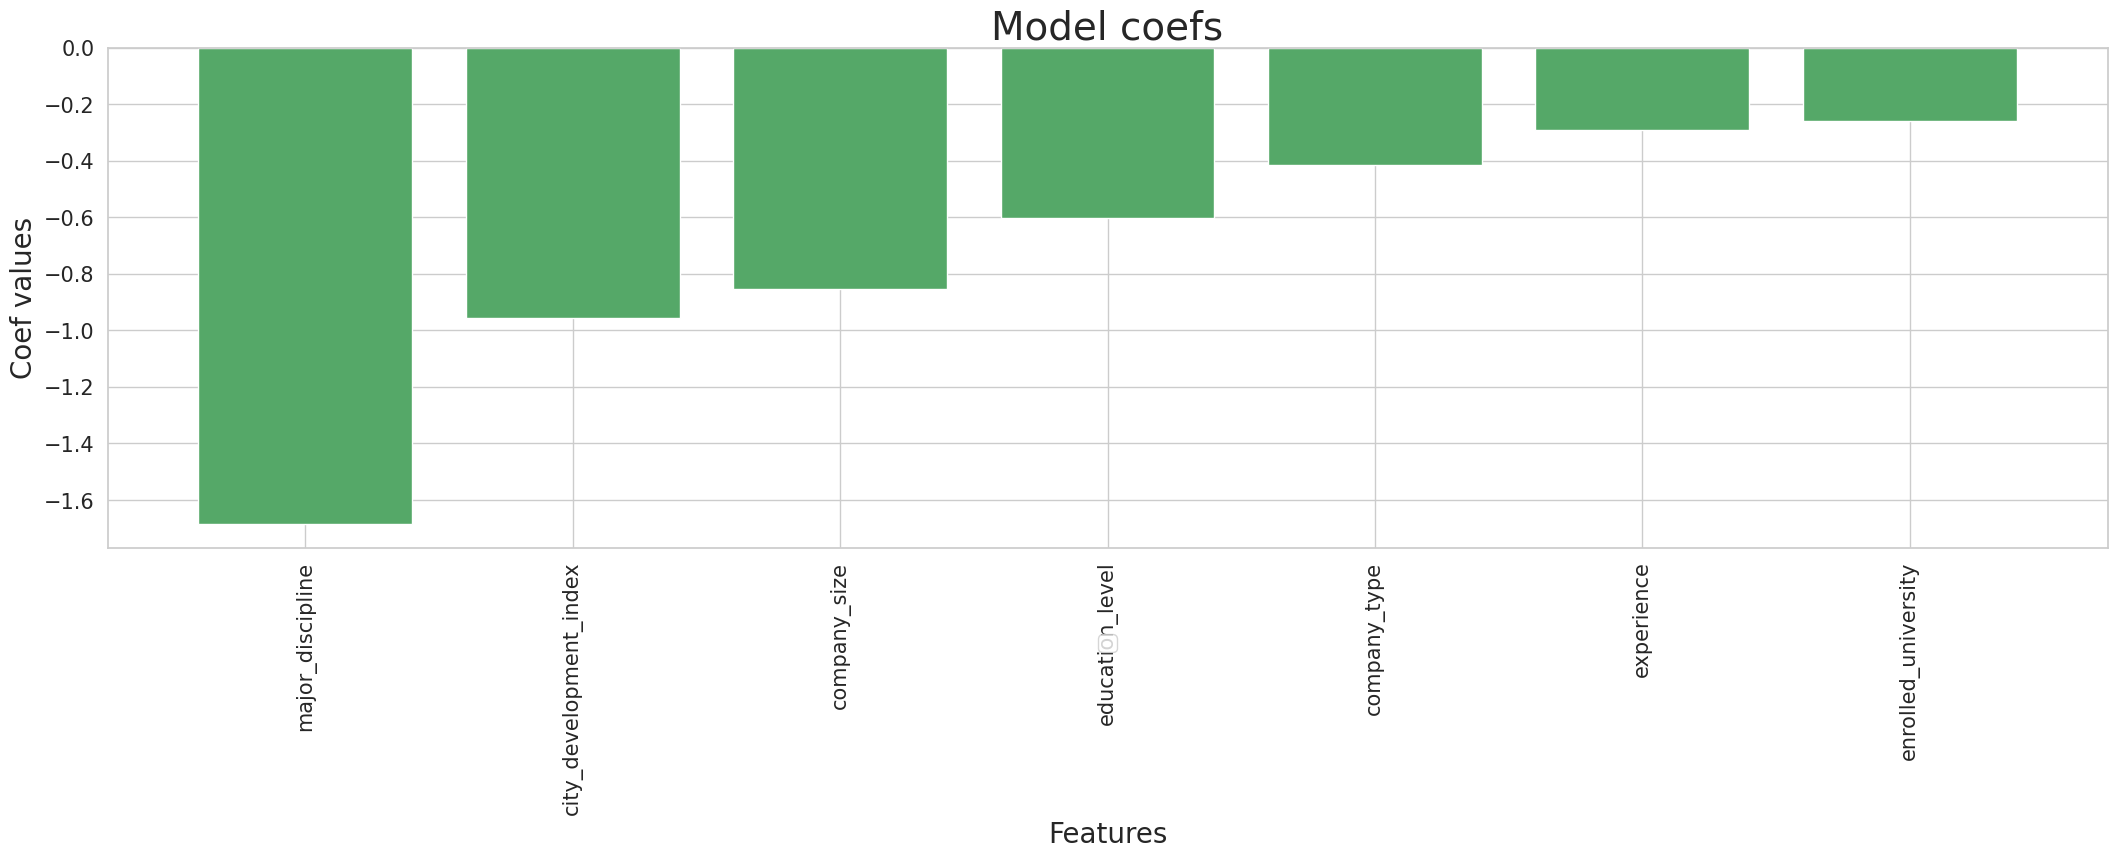

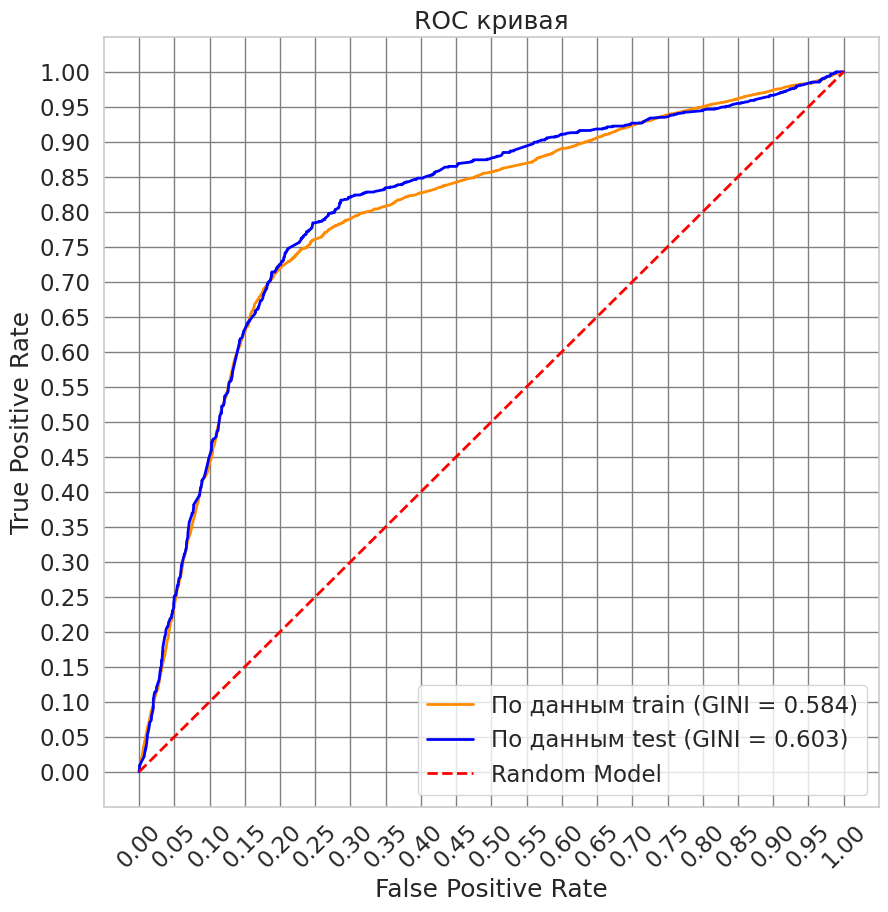

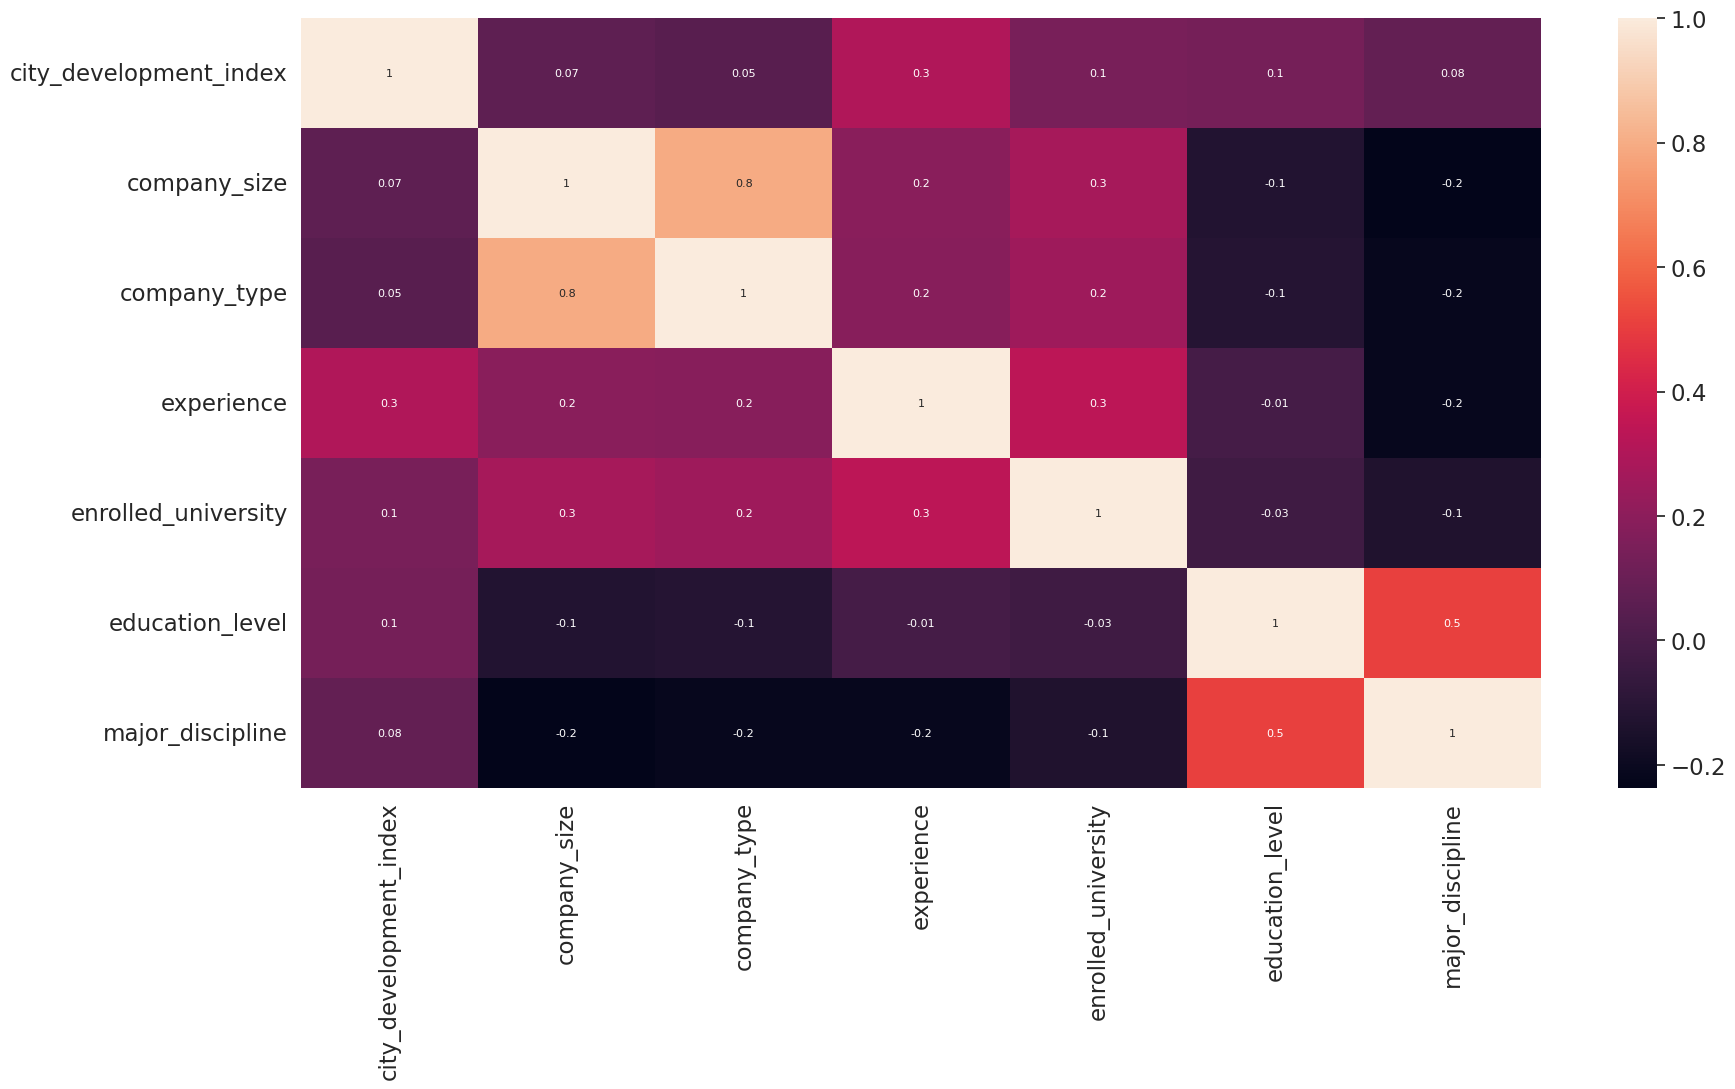

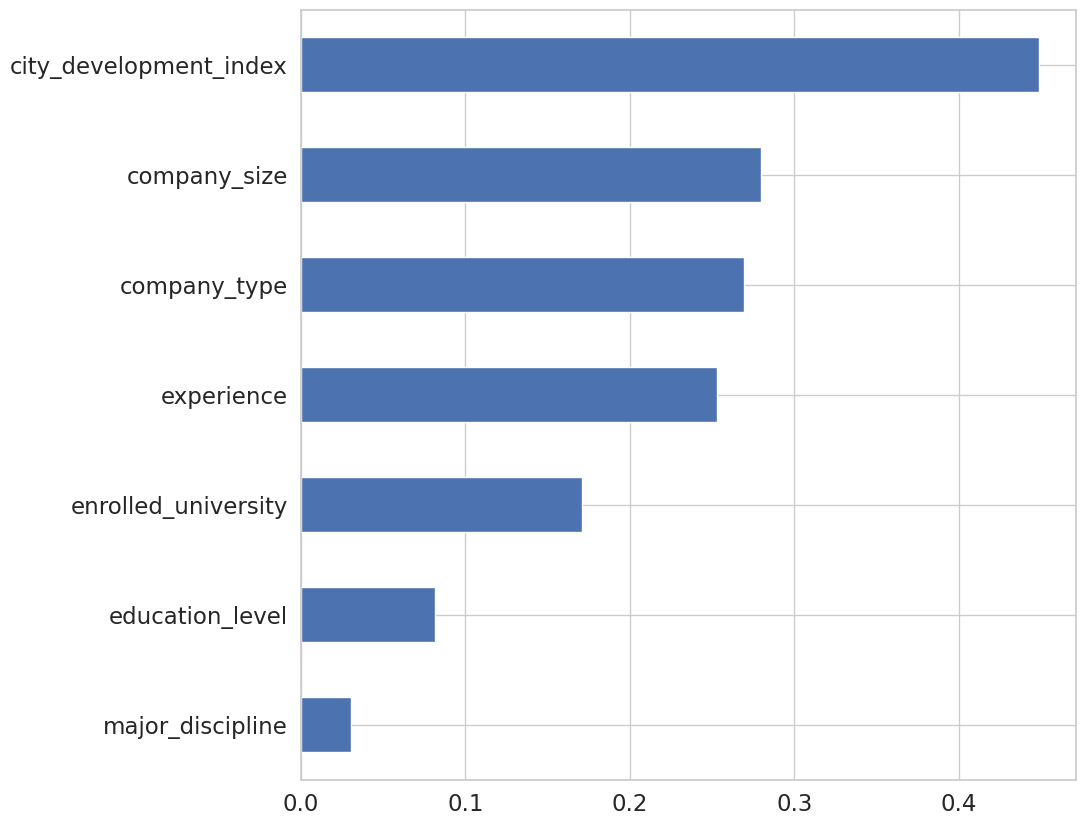

Еще больше хороших туториалов:

https://github.com/sberbank-ai-lab/LightAutoML/blob/master/examples

## Спасибо за внимание

Tg: @serega200010

VK: https://vk.com/mm_ml_team

Email: sergei.artamonov@math.msu.ru


Любые вопросы, идеи и предложения:


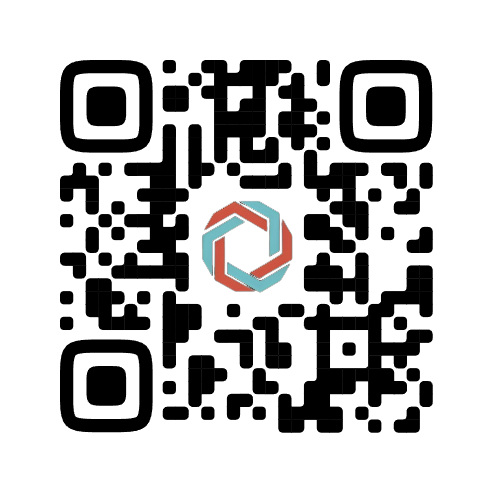

# Дополнительные материалы:

- https://www.youtube.com/watch?v=tqtTHRwa8dE - лекция Андреаса Мюллера
- https://www.youtube.com/watch?v=3_E4A4G7nME&feature=youtu.be -Лекция Лариуса Миндалуэра
- https://neptune.ai/blog/hyperband-and-bohb-understanding-state-of-the-art-hyperparameter-optimization-algorithms - Туториал Bahmani
- Лекция Алексея Зайцева - https://www.youtube.com/watch?v=I3dJ0d-80KY&t=1844s

# Доп. инструменты:
- HpBandSter - https://github.com/automl/HpBandSter?tab=readme-ov-file
- SMAC3 - https://github.com/automl/SMAC3?tab=readme-ov-file